11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training shape: (60000, 784)
Test shape: (10000, 784)
Epoch 1
Train Loss: 0.4561
Train Acc : 0.8827
Test  Acc : 0.8884
------------------------------
Epoch 2
Train Loss: 0.3580
Train Acc : 0.9025
Test  Acc : 0.9076
------------------------------
Epoch 3
Train Loss: 0.3178
Train Acc : 0.9120
Test  Acc : 0.9153
------------------------------
Epoch 4
Train Loss: 0.2927
Train Acc : 0.9188
Test  Acc : 0.9213
------------------------------
Epoch 5
Train Loss: 0.2728
Train Acc : 0.9239
Test  Acc : 0.9268
------------------------------
Epoch 6
Train Loss: 0.2575
Train Acc : 0.9282
Test  Acc : 0.9316
------------------------------
Epoch 7
Train Loss: 0.2442
Train Acc : 0.9315
Test  Acc : 0.9335
------------------------------
Epoch 8
Train Loss: 0.2319
Train Acc : 0.9351
Test  Acc : 0.9368
------------------------------
Epoch 9
Train Loss: 0.2217
Train Acc : 0.9386
Test  Acc : 0.9384
------------------------------
Epoch 10
Train Loss: 0.2121
Tra

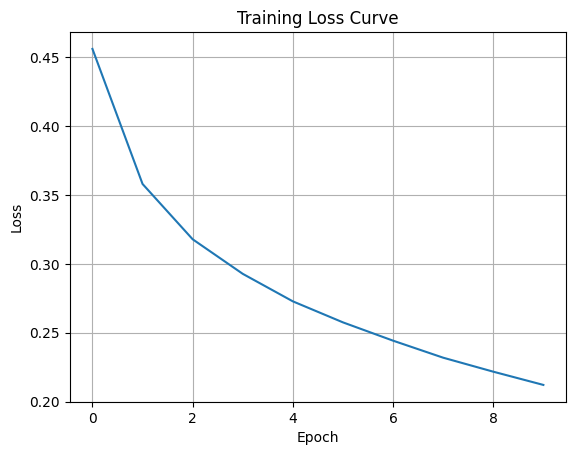

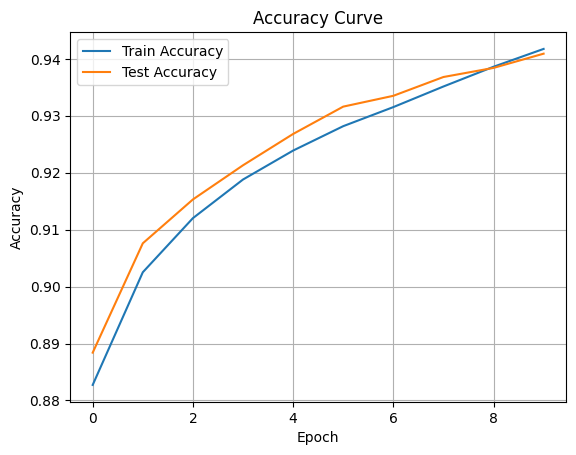

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist


# Load MNIST

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten 28x28 → 784
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)


# Activation Functions

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))  # Stability fix
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)


# Loss Function

def cross_entropy(y_true, y_pred):
    m = y_true.shape[0]
    log_likelihood = -np.log(y_pred[range(m), y_true] + 1e-9)
    return np.sum(log_likelihood) / m


# MLP Class

class MLP:
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        self.lr = lr

        # He Initialization (better for ReLU)
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2. / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2. / hidden_size)
        self.b2 = np.zeros((1, output_size))

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = relu(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = softmax(self.z2)
        return self.a2

    def backward(self, X, y, output):
        m = X.shape[0]

        # FIX: copy output before modifying
        dz2 = output.copy()
        dz2[range(m), y] -= 1
        dz2 /= m

        dW2 = np.dot(self.a1.T, dz2)
        db2 = np.sum(dz2, axis=0, keepdims=True)

        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * relu_derivative(self.z1)

        dW1 = np.dot(X.T, dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # Update weights
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2


# Training Function

def train(model, X_train, y_train, X_test, y_test, epochs=10, batch_size=64):
    n = X_train.shape[0]

    train_losses = []
    train_accs = []
    test_accs = []

    for epoch in range(epochs):

        # Safe shuffling
        permutation = np.random.permutation(n)
        X_shuffled = X_train[permutation]
        y_shuffled = y_train[permutation]

        # Mini-batch training
        for i in range(0, n, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            output = model.forward(X_batch)
            model.backward(X_batch, y_batch, output)

        # ---- Metrics ----
        train_preds = model.forward(X_train)
        train_loss = cross_entropy(y_train, train_preds)
        train_acc = np.mean(np.argmax(train_preds, axis=1) == y_train)

        test_preds = model.forward(X_test)
        test_acc = np.mean(np.argmax(test_preds, axis=1) == y_test)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        print(f"Epoch {epoch+1}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Train Acc : {train_acc:.4f}")
        print(f"Test  Acc : {test_acc:.4f}")
        print("-"*30)

    return train_losses, train_accs, test_accs


# Run Model

model = MLP(784, 256, 10, lr=0.01)

losses, train_accs, test_accs = train(
    model,
    X_train, y_train,
    X_test, y_test,
    epochs=10,
    batch_size=64
)


# Plot Loss

plt.figure()
plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


# Plot Accuracy

plt.figure()
plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Training shape: (60000, 784)
Testing shape: (10000, 784)
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.3283 - val_loss: 0.1519
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1430 - val_loss: 0.1203
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1188 - val_loss: 0.1099
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1100 - val_loss: 0.1045
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1051 - val_loss: 0.1005
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.1010 - val_loss: 0.0980
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0982 - val_loss: 0.0956
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0964 - val_loss: 0.0944
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0952 - val_loss: 0.0933
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0940 - val_loss: 0.0923
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0930 - v

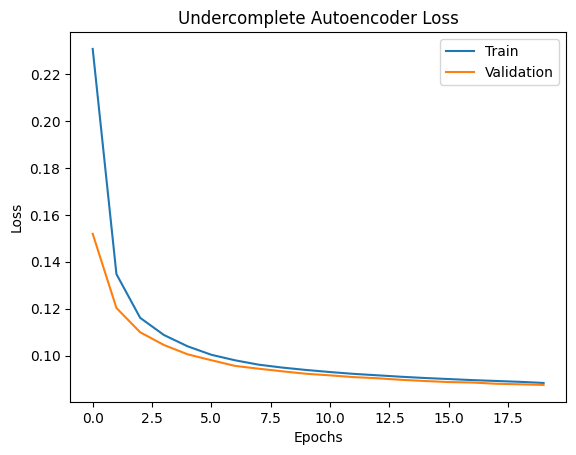

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


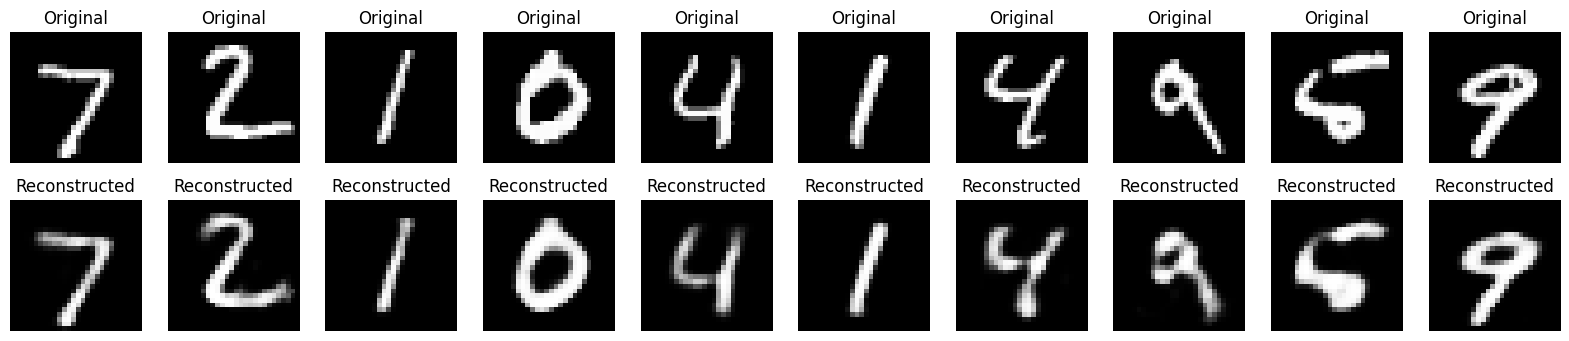

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.3982 - val_loss: 0.2409
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.2332 - val_loss: 0.2123
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.2076 - val_loss: 0.1893
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1872 - val_loss: 0.1797
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1793 - val_loss: 0.1748
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1747 - val_loss: 0.1710
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1716 - val_loss: 0.1684
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1687 - val_loss: 0.1663
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1667 - val_loss: 0.1644
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.1651 - val_loss: 0.1630
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1636 - val_loss: 0.1617
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

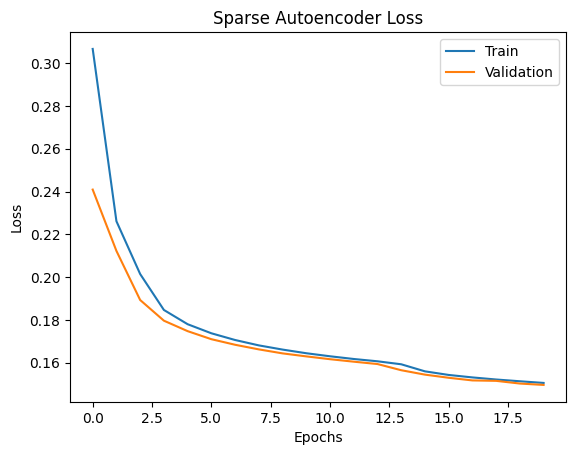

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Outlier Threshold: 0.05388973
Number of Outliers: 323


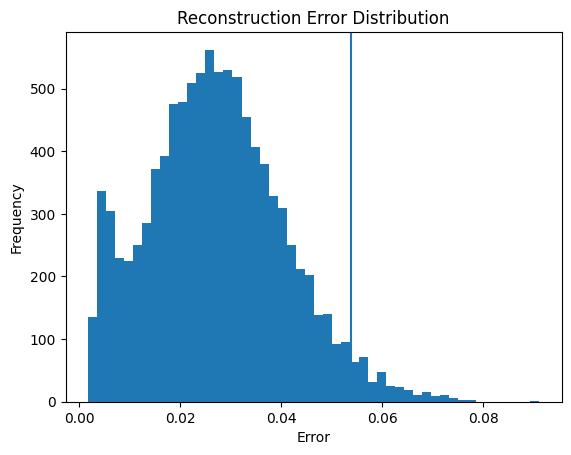

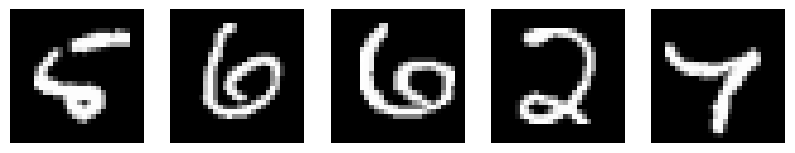

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Latent Vector Shape: (10000, 32)
Autoencoder Project Completed Successfully ✅


In [2]:

# COMPLETE AUTOENCODER PROJECT (ALL PARTS IN ONE CODE)
# Dataset: MNIST


import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam


# STEP 1: Load and Prepare Dataset


(x_train, _), (x_test, _) = mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

# Flatten images (28x28 → 784)
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

input_dim = 784
encoding_dim = 32


# PART 1: UNDERCOMPLETE AUTOENCODER


input_img = Input(shape=(input_dim,))

# Encoder
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

# Models
autoencoder = Model(input_img, decoded)
encoder = Model(input_img, encoded)

autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy'
)

history = autoencoder.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=1
)

# Plot Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Undercomplete Autoencoder Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

# Show Reconstructions
decoded_imgs = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")
plt.show()


# PART 2: SPARSE AUTOENCODER (L1 Regularization)


input_img_sparse = Input(shape=(input_dim,))

encoded_sparse = Dense(128, activation='relu')(input_img_sparse)
encoded_sparse = Dense(
    encoding_dim,
    activation='relu',
    activity_regularizer=regularizers.l1(1e-5)
)(encoded_sparse)

decoded_sparse = Dense(128, activation='relu')(encoded_sparse)
decoded_sparse = Dense(input_dim, activation='sigmoid')(decoded_sparse)

sparse_autoencoder = Model(input_img_sparse, decoded_sparse)
sparse_encoder = Model(input_img_sparse, encoded_sparse)

sparse_autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy'
)

history_sparse = sparse_autoencoder.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=1
)

# Plot Sparse Loss
plt.figure()
plt.plot(history_sparse.history['loss'])
plt.plot(history_sparse.history['val_loss'])
plt.title("Sparse Autoencoder Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()


# PART 3: OUTLIER DETECTION


# Single prediction call (efficient)
reconstructions = sparse_autoencoder.predict(x_test)

# Reconstruction error (MSE per sample)
reconstruction_error = np.mean(
    np.square(x_test - reconstructions),
    axis=1
)

threshold = np.mean(reconstruction_error) + 2 * np.std(reconstruction_error)
print("Outlier Threshold:", threshold)

outliers = reconstruction_error > threshold
print("Number of Outliers:", np.sum(outliers))

# Plot error distribution
plt.figure()
plt.hist(reconstruction_error, bins=50)
plt.axvline(threshold)
plt.title("Reconstruction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

# Safe Outlier Display
outlier_indices = np.where(outliers)[0]

if len(outlier_indices) > 0:
    plt.figure(figsize=(10, 4))
    num_display = min(5, len(outlier_indices))
    for i in range(num_display):
        plt.subplot(1, num_display, i + 1)
        plt.imshow(x_test[outlier_indices[i]].reshape(28, 28), cmap='gray')
        plt.axis("off")
    plt.show()


# PART 4: LATENT VECTOR EXTRACTION


latent_vectors = sparse_encoder.predict(x_test)
print("Latent Vector Shape:", latent_vectors.shape)

print("Autoencoder Project Completed Successfully ✅")